# Toy models: invariance to contrastive peak permutations

Measures how far a spectrum moves on the latent sphere when some of its peaks are permuted, which is exactly the transformation InfoNCE treats as a positive pair. It answers whether the contrastive term makes the encoder invariant to permutations of unannotated peaks while keeping it sensitive to annotated ones.

## Introduction

The toy campaign (`kidney-representative-toy`) trains cumulative objectives on one small kidney image with latent width $L = 4$, so that the whole latent space is $S^2$ and can be shown directly. Its figures are used in the conceptual presentation (`assets/documents/prestentations/segmentation_model_full_conceptual`).

### Assumptions

- One model per objective (one repetition). Differences between variants are single realizations, not
  estimates of an expected effect; the toy is illustrative, not a benchmark.
- All variants share the data split, the initialization seed and the training seed, so the only
  difference is the objective.
- Architecture, optimizer, loss parameters and loss weights follow the `real_only` schedule of the
  `20_09_26_metaspace_base_pretrain` campaign (without label-weighted contrastive negatives), including
  its 10 epochs; only `latent_dim` is smaller.
- Ten epochs on the training part of 16 230 pixels are about 2000 optimizer steps; the
  auxiliary terms (weights 0.2, 0.001, 0.002) contribute little to the objective, so differences between
  variants are expected to be small.
- Display categories are built from five selected ions (three spatially disjoint, one overlapping one of
  them, one present almost everywhere) by the rules in `analysis_settings.yaml`; names list the ions.

### Notation

| symbol | meaning |
|---|---|
| $x \in \Delta^{M-1}$ | TIC-normalized binned spectrum, $M = 1364$ bins of $0.55$ m/z on $[200, 950]$ |
| $a \in \mathbb{R}^{L}$ | encoder output before the bottleneck `LayerNorm`, $L = 4$ |
| $u = (a - \mu_a \mathbf 1)/\sigma_a$ | canonical latent, $\mathbf 1^\top u = 0$, $\lVert u \rVert = \sqrt L$ |
| $z = \gamma \odot u + \beta$ | model latent (affine `LayerNorm` output) |
| $s = Q^\top u / \lVert Q^\top u \rVert \in S^2$ | latent coordinates; $Q \in \mathbb{R}^{4 \times 3}$ fixed orthonormal basis of $\mathbf 1^\perp$ |
| $\mathcal M_0, \dots, \mathcal M_4$ | objectives: reconstruction; + head; + head + contrastive; + head + contractive; + head + both |
| $\angle(u, u')$ | angle between canonical latents, in degrees |

## Configuration

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from msi_autoencoder_wrapper.analysis.autoencoder.experiments import representative_toy_precompute as toy
from msi_autoencoder_wrapper.visualization import representative_toy as viz

SETTINGS = toy.load_settings(Path("analysis_settings.yaml"))
FIGURES = Path(SETTINGS["repository_root"]) / SETTINGS["figures"]["presentation_directory"]
LABELS = SETTINGS["campaign"]["labels"]
SHOWN = SETTINGS["campaign"]["presentation"]  # variants used on the slides
PREFIX = SETTINGS["figures"]["prefix"]
REGION_COLORS = {rule["name"]: rule["color"] for rule in SETTINGS["regions"]}

classes = toy.load_table(SETTINGS, "dataset", "classes")
pixels = toy.load_table(SETTINGS, "dataset", "pixels")
pixels["region"] = toy.assign_regions(pixels, classes, SETTINGS["regions"])

2026-09-24 02:34:38,155 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 1 implementation module(s) in package 'msi_autoencoder_wrapper.binners.binners_strategies'.


2026-09-24 02:34:38,160 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 6 implementation module(s) in package 'msi_autoencoder_wrapper.binners.inverse_strategies'.


2026-09-24 02:34:38,808 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 3 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.autoencoders.presets'.


2026-09-24 02:34:38,811 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 28 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.autoencoders'.


2026-09-24 02:34:38,842 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 0 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.schema'.


2026-09-24 02:34:38,843 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 46 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures'.


2026-09-24 02:34:38,885 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 2 implementation module(s) in package 'msi_autoencoder_wrapper.models.datasets.strategies'.


2026-09-24 02:34:38,908 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 29 implementation module(s) in package 'msi_autoencoder_wrapper.training.criterions.autoencoder'.


2026-09-24 02:34:38,912 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 33 implementation module(s) in package 'msi_autoencoder_wrapper.training.criterions'.


## Producing the tables this notebook reads

The tables are written by the toy precomputation module; the command below is generated by that module.

In [2]:
print(toy.run_command(SETTINGS, "contrastive_views"))

nohup /home/max/repositories/MSIAutoEncoderWrapper/.venv/bin/python -m msi_autoencoder_wrapper.analysis.autoencoder.experiments.representative_toy_precompute --settings /home/max/repositories/MSIAutoEncoderWrapper/assets/experiments/autoencoder_architecture/notebooks/representative_model/24_09_26_toy_presentation/analysis_settings.yaml --analysis contrastive_views > /home/max/repositories/MSIAutoEncoderWrapper/assets/experiments/autoencoder_architecture/notebooks/representative_model/24_09_26_toy_presentation/precompute.log 2>&1 &


## Latent angle between a spectrum and its permuted views

### Methodology

#### Theoretical

A view $\tilde x = T(x)$ cyclically permutes the shapes of three peak envelopes of $x$ while keeping TIC. `permutation_label_invariant` permutes only envelopes that do not overlap an annotated bin; `permutation_random` may permute annotated peaks too. The measured quantity is $\angle(u(x), u(\tilde x))$; smaller means more invariant.

#### Implementation

Views are generated by the training criterion (`InfoNCELoss.on_phase_start` / `on_batch_start`) with the parameters of the contrastive variant, 8 views per pixel and method, and reused for every variant.

#### Figure descriptions

x = variant; for each variant two boxes (plain = label-invariant views, hatched = random views) with all individual pixel-view angles as points; y = latent angle in degrees; colour = variant.

In [3]:
angles = toy.load_table(SETTINGS, "contrastive_views", "angles")
views = toy.load_table(SETTINGS, "contrastive_views", "views")
display(views.groupby("method").l1_change.describe()[["mean", "50%", "max"]])
display(angles.groupby(["variant", "method"], sort=False).latent_angle_deg.median().unstack())

,mean,50%,max
method,,,
permutation_label_invariant,0.032265,0.018907,0.718369
permutation_random,0.034859,0.019492,0.718369


method,permutation_label_invariant,permutation_random
variant,,
m0-reconstruction,0.656057,0.686113
m1-head,0.627250,0.656868
m2-head-contrastive,0.605323,0.647262
m3-head-contractive,0.651782,0.686415
m4-head-contrastive-contractive,0.613511,0.652527


/home/max/repositories/MSIAutoEncoderWrapper/src/msi_autoencoder_wrapper/visualization/representative_toy.py:85: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  figure.savefig(path)


/home/max/repositories/MSIAutoEncoderWrapper/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


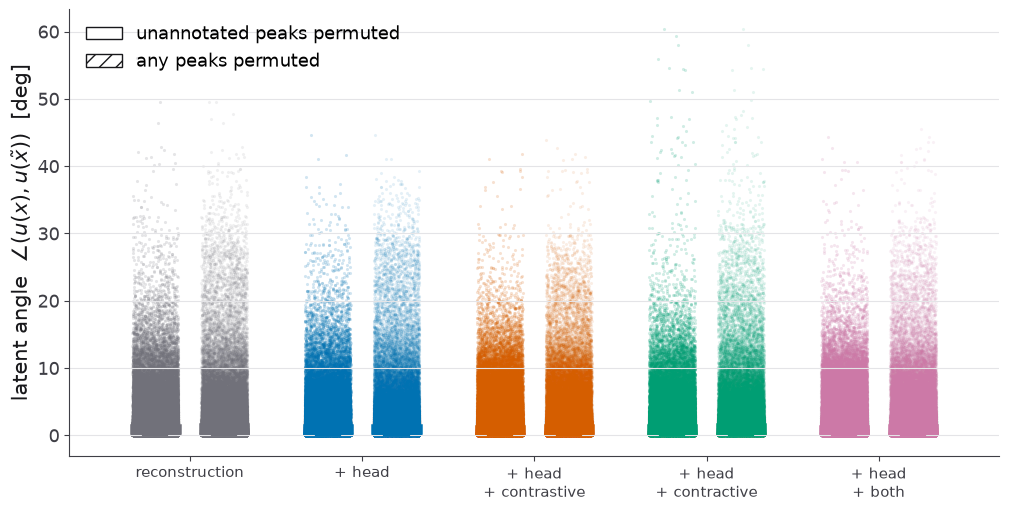

In [4]:
with viz.presentation_style():
    figure = viz.plot_angle_distributions(angles, group="method", labels=LABELS,
        group_labels={"permutation_label_invariant": "unannotated peaks permuted", "permutation_random": "any peaks permuted"})
    viz.save_figure(figure, FIGURES, PREFIX + "contrastive_angles")
    plt.show()

### Remarks

### Notes

## Permuted views of selected pixels on the sphere

### Methodology

#### Theoretical

For one pixel per annotated region, many label-invariant views $\tilde x$ are mapped to the sphere; the spread of the views around the original point visualizes how invariant the encoder is to the permutation that InfoNCE treats as a positive pair.

#### Implementation

48 label-invariant views per display pixel, generated once by the criterion and mapped by each variant; display pixels are the pixels nearest to the spatial centroid of each region.

#### Figure descriptions

One sphere per variant (+ head against + head + contrastive, then + head against + head + both); large outlined points = original pixels, small points = their permuted views; colour = category of the pixel.

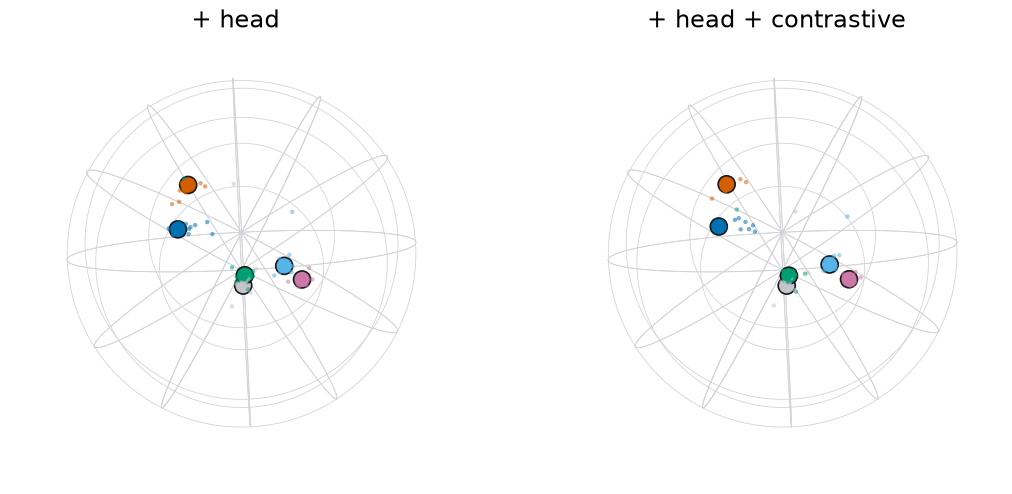

In [5]:
cloud = toy.load_table(SETTINGS, "contrastive_views", "display_cloud")
cloud = cloud[cloud.method == "permutation_label_invariant"]
region_of = dict(zip(pixels.source_id, pixels.region))
with viz.presentation_style():
    figure = viz.plot_perturbation_clouds([(LABELS[v], cloud[cloud.variant == v]) for v in ("m1-head", SHOWN["contrastive"])],
                                          region_of, REGION_COLORS, moved_kind="view")
    viz.save_figure(figure, FIGURES, PREFIX + "contrastive_clouds")
    plt.show()

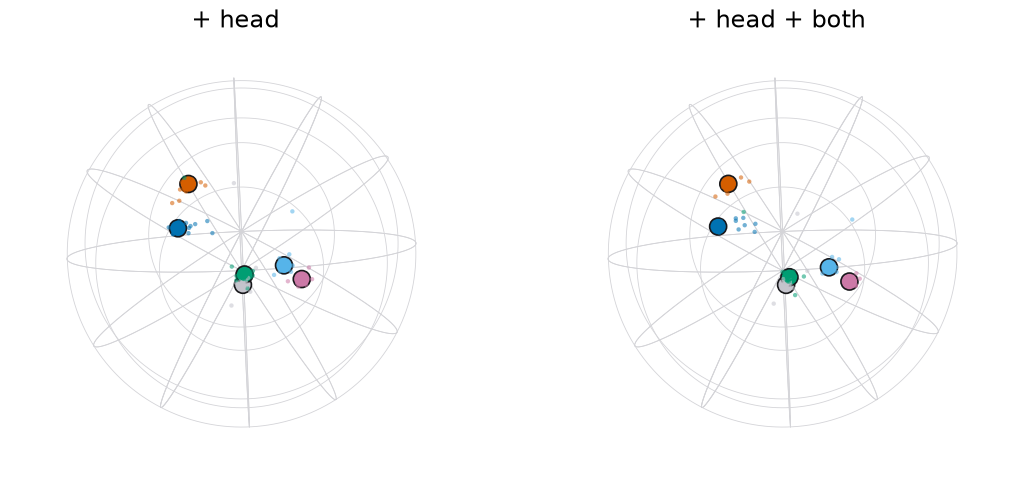

In [6]:
with viz.presentation_style():
    figure = viz.plot_perturbation_clouds([(LABELS[v], cloud[cloud.variant == v]) for v in ("m1-head", SHOWN["both"])],
                                          region_of, REGION_COLORS, moved_kind="view")
    viz.save_figure(figure, FIGURES, PREFIX + "contrastive_clouds_both")
    plt.show()

### Remarks

### Notes

## Results / Summary

### LLM

### Person